In [1]:
#!git clone https://github.com/whyhardt/SPICE.git

In [2]:
# !pip install -e SPICE

In [3]:
import sys
import torch

from spice import SpiceEstimator

sys.path.append('../../..')
from weinhardt2026.utils.benchmarking_gru import GRUModel, training
from benchmarking_ganesh2024a import get_dataset, generate_behavior, BayesianModel
from spice_ganesh2024a import SpiceModel, CONFIG

# NOTEBOOK CONFIGURATION

In [4]:
train_spice = True
train_bay = False
train_gru = False

# Load dataset

Let's load the data first with the `csv_to_dataset` method. This method returns a `SpiceDataset` object which we can use right away 

In [5]:
path_data = 'data/ganesh2024a_choice.csv'
test_blocks = (3, 6, 9)
dataset_train, dataset_test, info_dataset = get_dataset(path_data=path_data, test_blocks=test_blocks, verbose=True)

Shape of dataset: torch.Size([1176, 24, 1, 11])
Number of participants: 98
Number of actions: 2


# SPICE Setup

In [6]:
path_spice = 'params/spice_ganesh2024a.pkl'

estimator = SpiceEstimator(
    # model paramaeters
    spice_class=SpiceModel,
    spice_config=CONFIG,
    n_actions=dataset_train.n_actions,
    n_participants=dataset_train.n_participants,
    
    epochs=1000,
    warmup_steps=500,
    ensemble_size=1,
    
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    verbose=True,
    save_path_spice=path_spice,
)


In [7]:
if train_spice:
    # fitting SPICE with SINDy as RNN-regularizer
    print(f"\nStarting training on {estimator.device}...")
    estimator.fit(dataset_train.xs, dataset_train.ys, dataset_test.xs, dataset_test.ys)

100%|█████████████████████████| 1000/1000 [05:31<00:00,  3.01it/s, L(Train)=0.3698539, L(Val,RNN)=0.4290315, L(Val,SINDy)=0.4676348, Conv=2.05e-04, LR=1.00e-02]
----------------------------------------------------------------------------------------------------------------------------------------------------------------
SPICE Model (Coefficients: 27):
perception_certainty[t+1]     = 0.73 1 + 0.008 contr_diff[t] + 1.716 contr_diff[t]^2 
reward_learning_chosen[t+1]   = -0.28 1 + 0.688 reward_learning_chosen[t] + 1.211 reward[t] + 0.03 certainty[t] + 0.043 reward_learning_chosen^2 + -0.359 reward_learning_chosen*reward[t] + -0.065 reward_learning_chosen*certainty[t] + 1.216 reward[t]^2 + 0.512 reward[t]*certainty[t] + 0.138 certainty[t]^2 
reward_learning_unchosen[t+1] = -0.003 1 + 0.697 reward_learning_unchosen[t] + 0.01 certainty[t] + 0.0 reward_learning_unchosen^2 + -0.093 reward_learning_unchosen*certainty[t] + 0.293 certainty[t]^2 
choice_persistance[t+1]       = 0.267 1 + 0.977 choi

100%|██████████| 1000/1000 [00:25<00:00, 38.68it/s, loss=0.0127614, lr=2.0e-05, n_params=29.92+/-1.72]



Stage 2.2: SINDy coefficient estimation (multi-step shooting, K=100)
Ridge regression succeeded (K=24 loss: 0.1218087). Running SGD refinement...


100%|██████████| 1000/1000 [03:10<00:00,  5.26it/s, K=24, loss=0.0820264, lr=1.0e-05, n_params=29.92+/-1.72]



Losses:
	         Training    Validation
	RNN      0.35472     0.42903
	SINDy    0.40159     0.46608

RNN training finished.
Training took 548.60 seconds.
Saving SPICE model to params/spice_ganesh2024a.pkl...


Once a model is trained and saved we can load it from the pickle file using `SpiceEstimator.load_spice(path_to_model)`

In [8]:
estimator.load_spice(path_spice)

The SPICE models can be printed to the console using `SpiceEstimator.print_spice_model(participant_id)` 

In [9]:
# Print example SPICE model
participant_id = 0
print(f"\nExample SPICE model for participant {participant_id}:")
estimator.print_spice_model(participant_id=participant_id)


Example SPICE model for participant 0:
perception_certainty[t+1]     = 0.69 1 + -0.016 contr_diff[t] + 1.629 contr_diff[t]^2 
reward_learning_chosen[t+1]   = -0.874 1 + 0.703 reward_learning_chosen[t] + 1.407 reward[t] + 1.572 certainty[t] + 0.041 reward_learning_chosen^2 + -0.329 reward_learning_chosen*reward[t] + -0.109 reward_learning_chosen*certainty[t] + 0.82 reward[t]^2 + 0.764 reward[t]*certainty[t] + -0.747 certainty[t]^2 
reward_learning_unchosen[t+1] = 0.774 1 + 0.554 reward_learning_unchosen[t] + -1.51 certainty[t] + 0.028 reward_learning_unchosen^2 + -0.06 reward_learning_unchosen*certainty[t] + 1.114 certainty[t]^2 
choice_persistance[t+1]       = 0.13 1 + 0.985 choice_persistance[t] + -0.006 choice[t] + -0.244 certainty[t] + 0.608 certainty_next[t+1] + -0.026 choice_persistance*choice[t] + 0.084 choice_persistance*certainty[t] + -0.059 choice_persistance*certainty_next[t+1] + 0.05 choice[t]^2 + 0.165 choice[t]*certainty[t] + -0.197 choice[t]*certainty_next[t+1] + -1.361 

# Benchmark models

## Classic benchmark model 

In [10]:
bay = BayesianModel(n_participants=info_dataset['n_participants'], batch_first=True)
path_bay = path_spice.replace('spice_', 'bay_')

In [11]:
if train_bay:
    epochs = 1000
    optimizer = torch.optim.Adam(bay.parameters(), lr=0.01)

    gru = training(
        model=bay,
        optimizer=optimizer,
        dataset_train=dataset_train,
        dataset_test=dataset_test,
        epochs=epochs,
        device=torch.device('cpu'),
        )
    
    torch.save(gru.state_dict(), path_bay)
    print("Trained benchmark parameters saved to " + path_bay)

In [12]:
bay.load_state_dict(torch.load(path_bay))

<All keys matched successfully>

## GRU benchmark model

In [13]:
gru = GRUModel(
    n_actions=info_dataset['n_actions'], 
    n_participants=info_dataset['n_participants'],
    additional_inputs=2, 
    dropout=0.25,
    embedding_size=8,
    hidden_size=8,
    )
path_gru = path_spice.replace('spice_', 'gru_')

In [14]:
if train_gru:
    epochs = 1000
    optimizer = torch.optim.Adam(gru.parameters(), lr=0.01)

    gru = training(
        model=gru,
        optimizer=optimizer,
        dataset_train=dataset_train,
        dataset_test=dataset_test,
        epochs=epochs,
        device=torch.device('cpu'),
        )

    torch.save(gru.state_dict(), path_gru)
    print("Trained GRU parameters saved to " + path_gru)

In [15]:
gru.load_state_dict(torch.load(path_gru, map_location='cpu'))

<All keys matched successfully>

# ANALYSIS

In [16]:
from weinhardt2026.analysis.analysis_coefficients_individuals import analysis_coefficients_individuals
from weinhardt2026.analysis.analysis_model_evaluation import analysis_model_evaluation
from weinhardt2026.analysis.analysis_coefficients_distributions import analysis_coefficients_distributions

In [17]:
estimator.eval()
bay.eval()
gru.eval()

GRUModel(
  (participant_embedding): Embedding(98, 8)
  (experiment_embedding): Embedding(1, 8)
  (linear_in): Linear(in_features=14, out_features=8, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (gru): GRU(8, 8, batch_first=True)
  (linear_out): Linear(in_features=8, out_features=2, bias=True)
)

## Analysis of trial averaged accuracy

In [18]:
analysis_model_evaluation(
    dataset=dataset_train,
    spice_model=estimator,
    gru_model=gru,
    benchmark_model=bay,
    )

Computing choice probabilities with benchmark model...
Computing choice probabilities with GRU model...
Computing choice probabilities with SPICE model...


,Trial Lik.,(std),n_parameters,(std),NLL,AIC,BIC,ΔBIC/trial
Benchmark,0.636894,0.143498,2.000000,0.000000,9549.998047,19103.996094,19119.916016,0.483048
GRU,0.691003,0.125997,1362.000000,0.000000,7823.922852,18371.845703,29213.701172,0.006206
SPICE-RNN,0.708558,0.138606,924.000000,0.000000,7292.884766,16433.769531,23789.037109,0.262474
SPICE-EQ,0.675302,0.141266,29.918367,1.721145,8310.455078,16680.746094,16918.904297,0.587026


In [19]:
analysis_model_evaluation(
    dataset=dataset_test,
    spice_model=estimator,
    gru_model=gru,
    benchmark_model=bay,
    output_dir='results',
    )

Computing choice probabilities with benchmark model...
Computing choice probabilities with GRU model...
Computing choice probabilities with SPICE model...


,Trial Lik.,(std),n_parameters,(std),NLL,AIC,BIC,ΔBIC/trial
Benchmark,0.612602,0.137542,2.000000,0.000000,3457.722656,6919.445312,6933.168457,0.403702
GRU,0.635455,0.143231,1362.000000,0.000000,3199.294434,9122.588867,18468.132812,-1.231071
SPICE-RNN,0.656962,0.144698,924.000000,0.000000,2964.426514,7776.853027,14117.001953,-0.614415
SPICE-EQ,0.632419,0.133074,29.918367,1.721145,3233.084717,6526.006348,6731.294922,0.432313


## Analysis generative behavior

In [20]:
estimator.eval()
estimator.use_sindy(False)
generated_dataset_spice = generate_behavior(
    dataset=dataset_train,
    model=estimator,
    save_dataset='data/ganesh2024a_spice_rnn.csv'
)

estimator.use_sindy(True)
generated_dataset_spice = generate_behavior(
    dataset=dataset_train,
    model=estimator,
    save_dataset='data/ganesh2024a_spice.csv'
)

generated_dataset_benchmark = generate_behavior(
    dataset=dataset_train,
    model=bay,
    save_dataset='data/ganesh2024a_benchmark.csv'
)

generated_dataset_gru = generate_behavior(
    dataset=dataset_train,
    model=gru,
    save_dataset='data/ganesh2024a_gru.csv'
)

Generating behavior...


100%|██████████| 24/24 [00:00<00:00, 285.86it/s]


Done generating behavior.
Generating behavior...


100%|██████████| 24/24 [00:00<00:00, 254.42it/s]


Done generating behavior.
Generating behavior...


100%|██████████| 24/24 [00:00<00:00, 561.80it/s]


Done generating behavior.
Generating behavior...


100%|██████████| 24/24 [00:00<00:00, 1491.18it/s]


Done generating behavior.


In [21]:
from analysis_generative import analysis_generative_behavior

Loading real from data/ganesh2024a_choice.csv...
Loading benchmark from data/ganesh2024a_benchmark.csv...
Loading gru from data/ganesh2024a_gru.csv...
Loading spice_rnn from data/ganesh2024a_spice.csv...
Loading spice from data/ganesh2024a_spice.csv...
                  Accuracy Accuracy (Low |Contrast|)  \
Model                                                  
real       0.468 +/- 0.346           0.482 +/- 0.306   
benchmark  0.706 +/- 0.170           0.654 +/- 0.157   
gru        0.684 +/- 0.218           0.656 +/- 0.199   
spice_rnn  0.760 +/- 0.227           0.745 +/- 0.243   
spice      0.760 +/- 0.227           0.745 +/- 0.243   

          Accuracy (Mid |Contrast|) Accuracy (High |Contrast|)  \
Model                                                            
real                0.472 +/- 0.402            0.449 +/- 0.352   
benchmark           0.761 +/- 0.253            0.693 +/- 0.215   
gru                 0.703 +/- 0.303            0.683 +/- 0.246   
spice_rnn           0.74

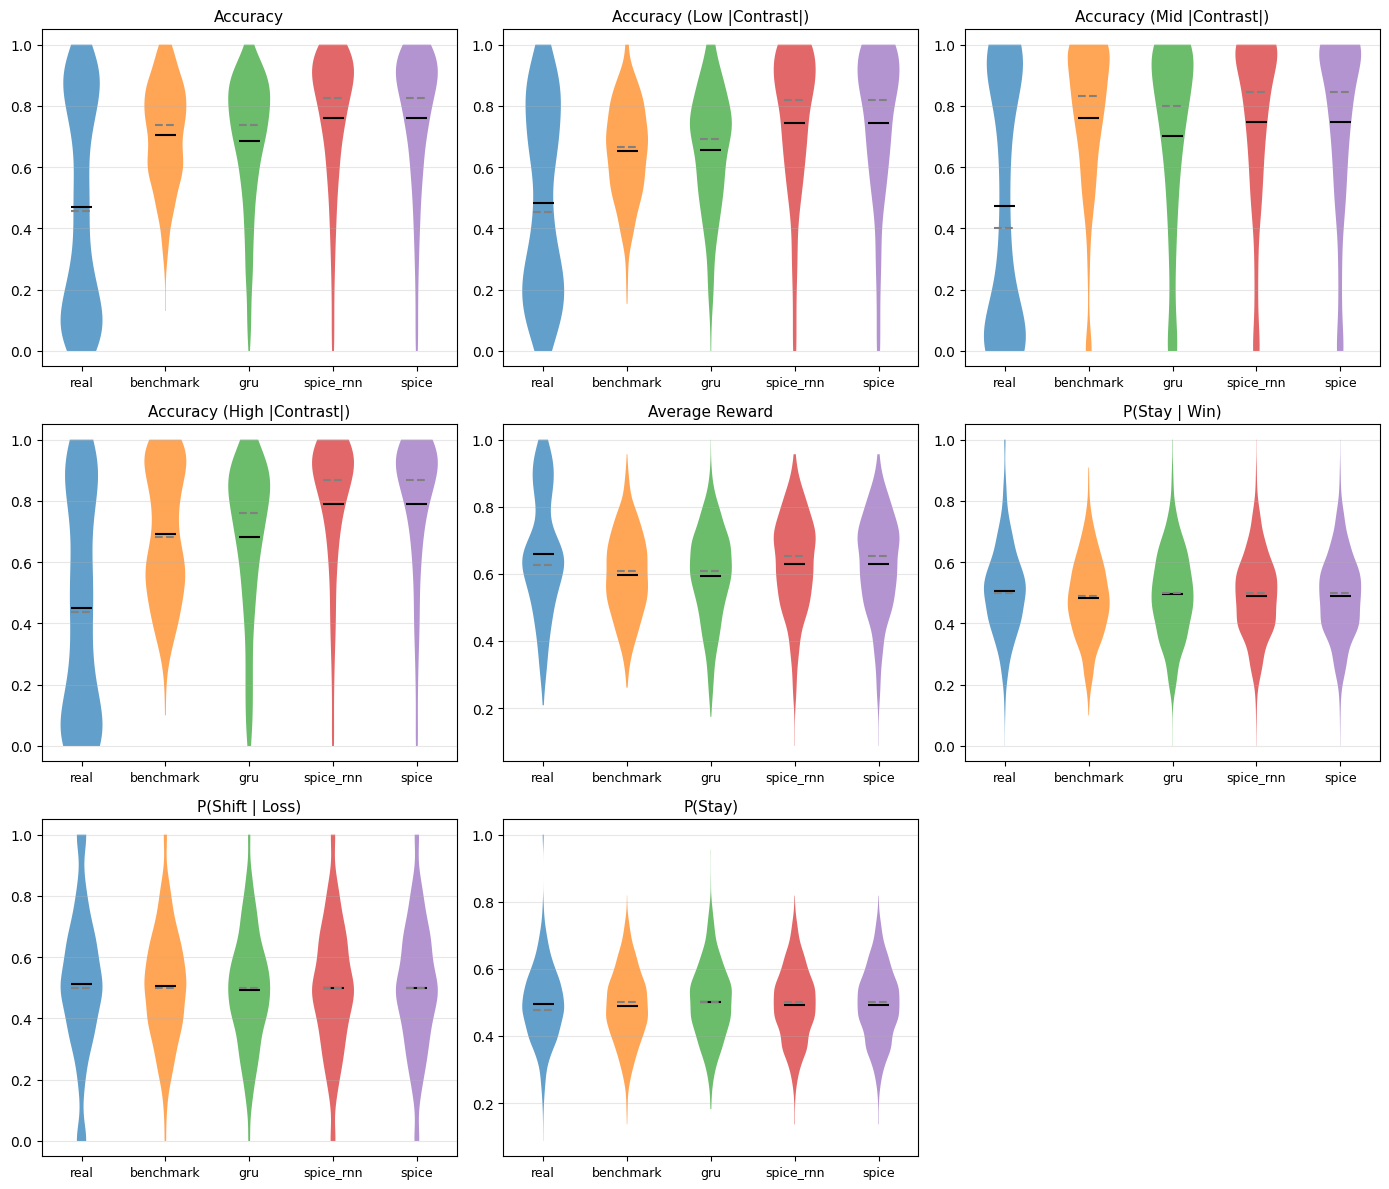


Normalized MAE (|model_mean - real_mean| / real_std):
          Accuracy Accuracy (Low |Contrast|) Accuracy (Mid |Contrast|)  \
Model                                                                    
benchmark   0.6849                    0.5611                    0.7195   
gru         0.6224                    0.5658                    0.5752   
spice_rnn   0.8410                    0.8571                    0.6839   
spice       0.8410                    0.8571                    0.6839   

          Accuracy (High |Contrast|) Average Reward P(Stay | Win)  \
Model                                                               
benchmark                     0.6924         0.3485        0.1615   
gru                           0.6648         0.3632        0.0760   
spice_rnn                     0.9666         0.1590        0.1134   
spice                         0.9666         0.1590        0.1134   

          P(Shift | Loss) P(Stay)     Aggregate NMAE  
Model                         

(                  Accuracy Accuracy (Low |Contrast|)  \
 Model                                                  
 real       0.468 +/- 0.346           0.482 +/- 0.306   
 benchmark  0.706 +/- 0.170           0.654 +/- 0.157   
 gru        0.684 +/- 0.218           0.656 +/- 0.199   
 spice_rnn  0.760 +/- 0.227           0.745 +/- 0.243   
 spice      0.760 +/- 0.227           0.745 +/- 0.243   
 
           Accuracy (Mid |Contrast|) Accuracy (High |Contrast|)  \
 Model                                                            
 real                0.472 +/- 0.402            0.449 +/- 0.352   
 benchmark           0.761 +/- 0.253            0.693 +/- 0.215   
 gru                 0.703 +/- 0.303            0.683 +/- 0.246   
 spice_rnn           0.747 +/- 0.287            0.789 +/- 0.227   
 spice               0.747 +/- 0.287            0.789 +/- 0.227   
 
             Average Reward    P(Stay | Win)  P(Shift | Loss)          P(Stay)  
 Model                                         

In [22]:
analysis_generative_behavior(
    path_data_real='data/ganesh2024a_choice.csv',
    path_data_benchmark='data/ganesh2024a_benchmark.csv',
    path_data_gru='data/ganesh2024a_gru.csv',
    path_data_spice_rnn='data/ganesh2024a_spice.csv',
    path_data_spice='data/ganesh2024a_spice.csv',
    output_dir='results',
)

## Analysis of individual differences (only SPICE)

This function analyses individual differences of the SPICE models w.r.t. the fitted SINDy coefficients.

Here you can choose between a discrete odds ratio analysis between groups (e.g. `HighAccumulatedReward` vs `LowAccumulatedReward`) or a beta-effect analysis of a continuous variable (e.g. `AccumulatedReward`).

The analyses check whether the given criterion is a good predictor of the SINDy coefficients in the model.

In [23]:
analysis_coefficients_individuals(
    path_model=path_spice,
    path_data=path_data,
    criterion="SomePerformanceColumnInDataset",
    analysis="disc", # also: "cont"
    reference="ReferenceGroupFromPerformanceColumn", # only necessary if analysis="disc"
    dir_output="../data/ganesh2024a/",
    model_class=SPICERNN,
    model_config=spice_config,
)

NameError: name 'SPICERNN' is not defined